# 앙상블 ( Ensemble )


In [1]:
import seaborn as sns
import pandas as pd

# 1. 펭귄 데이터셋 불러오기
penguins = sns.load_dataset('penguins')
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:

drop_col = [ 'species', 'island', 'sex']

X = penguins.drop(columns=drop_col) # 특성 데이터
y = penguins['body_mass_g'] # 타겟 데이터

display(X.head())
display(y.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


0    3750.0
1    3800.0
2    3250.0
3       NaN
4    3450.0
Name: body_mass_g, dtype: float64

In [3]:
from sklearn.model_selection import train_test_split

# 결측값 처리
X.fillna(0, inplace=True)
y.fillna(y.mean(), inplace=True)

# 학습/ 검증 데이터 설정
x_train, x_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# 모델 정의
rf_model = RandomForestRegressor(n_estimators = 20, random_state = 42)
gb_model = GradientBoostingRegressor(n_estimators = 20, random_state = 42)
et_model = ExtraTreesRegressor(n_estimators = 20, random_state = 42)

# 모델 학습
rf_model.fit(x_train, y_train)
gb_model.fit(x_train, y_train)
et_model.fit(x_train, y_train)

# 각 모델의 예측값 얻기
rf_preds = rf_model.predict(x_valid)
gb_preds = gb_model.predict(x_valid)
et_preds = et_model.predict(x_valid)

# 각 모델의 검증 점수 계산 (RMSE)
rf_score = root_mean_squared_error(y_valid, rf_preds)
gb_score = root_mean_squared_error(y_valid, gb_preds)
et_score = root_mean_squared_error(y_valid, et_preds)

# 검증 점수 출력
print("RandomForest RMSE 검증점수:", rf_score)
print("GradientBoosting RMSE검증 점수:", gb_score)
print("ExtraTrees RMSE 검증점수:", et_score)

RandomForest RMSE 검증점수: 53.16884342883583
GradientBoosting RMSE검증 점수: 105.09094246124221
ExtraTrees RMSE 검증점수: 26.20589243046157


# 평균 앙상블 

In [5]:
# 예측값 평균내기
avg_preds = (rf_preds + gb_preds + et_preds) / 3

# RMSE 검증 점수 계산
avg_score = root_mean_squared_error(y_valid, avg_preds)

print("평균 앙상블 RMSE 검증점수:", avg_score)

평균 앙상블 RMSE 검증점수: 45.4480534054124


# 5. 가중 평균 앙상블 ( Weighted Average Ensemble )

- 여러 모델의 예측 결과에 가중치를 부여하여 예측값을 결합하는 앙상블
- $( w_1 x modelresult_1 + w_2 x modelresult_2 + w_3 x modelresult_3 ) / 3$

## 장점

- 높은 성능을 가진 모델에 더 큰 가중치를 부여, 모델의 결과가 최종 예측에 더 많은 영향을 주도록 설계할 수 있다. 
- 평균 앙상블보다 높은 성능을 기대할 수 있다. 

## 단점

- 각 모델에 부여할 가중치를 선택하는게 어렵다. 
- 성능이 낮은 모델에 가중치가 부여 될 경우 최종 결과에 부정적 영향을 줄 수 있다. 

## 유의

- 가중치의 합은 1이 되어야 한다. 
- 모델이 예측한 값과 실제 값 간의 차이를 최소화 하기 위해 

In [6]:
import numpy as np

# 예측값에 가중치 적용하여 평균내기
weighted_avg_preds = (0.2 * rf_preds + 0.2 * gb_preds + 0.6 * et_preds)

# 가중 평균 검증 점수 계산 (RMSE)
weighted_avg_score = np.sqrt(
    mean_squared_error(y_valid, weighted_avg_preds)
)

# 검증 점수 출력
print("가중 평균 앙상블 RMSE 검증점수:", weighted_avg_score)

가중 평균 앙상블 RMSE 검증점수: 32.88965992723063


## 가중치 조합 탐색 

- 가중 평균을 구할 때 검증 점수를 바탕으로 모델 성능을 기준으로 임의로 모델별 가중치 부여 -> 평균 앙상블보다 높은 검증 점수를 얻을 수 있지만, 항상 최적의 검증 점수를 얻기는 어려울 수 있다. 
- 가능한 모든 가중치 조합에 대해 가중 평균을 계산하여 검증 점수를 비교하는 것
- 각 가중치 조합에 대한 모든 검증 점수를 얻을 수 있고, 이를 통해 가장 높은 검증 점수를 달성할 수 있다. 
- `가중치 조합을 다양하게 시험해 볼 수 있는 충분한 계산 자원과 시간이 있을 때 효과적으로 활용할 수 있다.` 

In [8]:
from itertools import product

# 가중치의 범위 설정
weights_range = np.arange(0.1, 0.9, 0.1)

# 가중치 조합 및 최적 점수 초기화
best_weights = None
best_score = float('inf')# 양의 무한대 

# 모든 가중치 조합 탐색, product함수는 입력으로 받은 시퀀스-> 가능한 모든 조합 생성 
for weights in product(weights_range, repeat=3):
    if sum(weights) != 1:  
        continue  
    
    # 앙상블 적용 및 RMSE 점수 계산
    weighted_avg_preds = (
        weights[0] * rf_preds + 
        weights[1] * gb_preds + 
        weights[2] * et_preds
    )
    
    weighted_avg_score = root_mean_squared_error(y_valid, weighted_avg_preds)

    # 최적의 가중치 조합과 점수 갱신
    if weighted_avg_score < best_score:
        best_weights = weights
        best_score = weighted_avg_score

# 최적의 가중치 조합과 점수 출력
print("최적 가중치 조합:", best_weights)
print("최적 RMSE 검증점수:", best_score)

최적 가중치 조합: (np.float64(0.2), np.float64(0.1), np.float64(0.7000000000000001))
최적 RMSE 검증점수: 26.446580011283856


## 검증 점수 기반 가중 평균 앙상블 

### 검증점수를 이용한 가중치 계산 

- 검증점수를 바탕으로 가중치를 설정하는 방법은 각 모델의 성능을 최적으로 활용하여 앙상블을 구성하기 위한 접근 방식 

1. 각 모델별로 검증 점수를 계산 
2. 각 모델의 검증 점수의 역수를 계산하여 가중치를 구한다. 
3. 역수로 계산된 모든 가중치의 합을 구한 후, 각 가중치를 합으로 나누어 정규화 한다. 

- 검증 점수의 역수를 계산
- 검증 점수가 낮을 수록 모델의 예측 정확도가 높아지므로, 역수를 통해 정확도가 높은 모델에 더 높은 가중치를 부여 할 수 있다. 

```python
rf_weight = 1 / rf_score
gb_weight = 1 / gb_score
et_weight = 1 / et_score
```

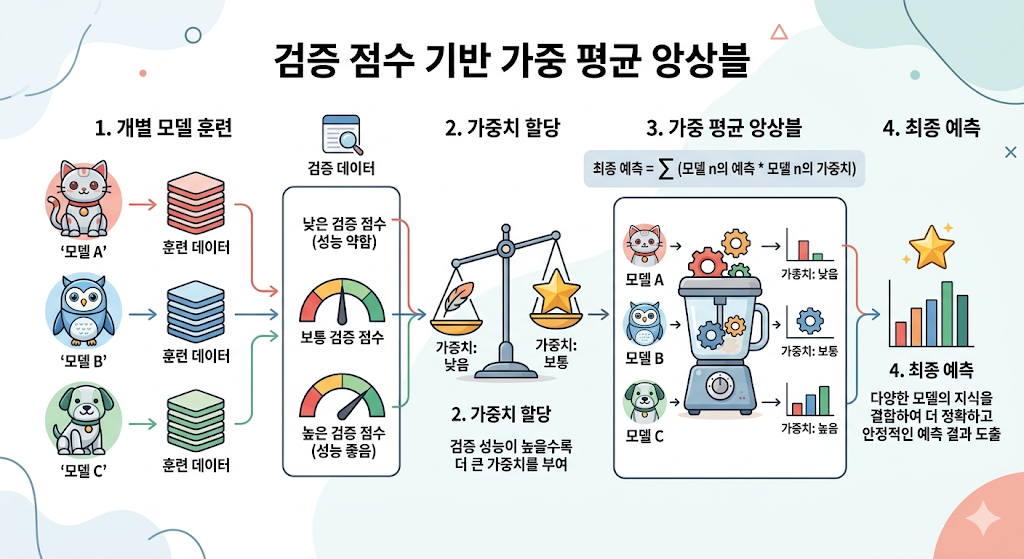

In [ ]:
# 각 모델의 검증 점수 계산 (RMSE)
rf_score = root_mean_squared_error(y_valid, rf_preds)
gb_score = root_mean_squared_error(y_valid, gb_preds)
et_score = root_mean_squared_error(y_valid, et_preds)
# MSE squeared를 계산
# RMSE 에서 root 씌우는 것, squared = False 
# 각 RMSE의 역수 계산 (가중치)
rf_weight = 1 / rf_score
gb_weight = 1 / gb_score
et_weight = 1 / et_score

# 가중치 정규화 (총합이 1이 되도록), 정규화 작업 
total_weight = rf_weight + gb_weight + et_weight
rf_weight /= total_weight
gb_weight /= total_weight
et_weight /= total_weight

In [9]:
# 가중 평균 예측값 계산
weighted_avg_preds = rf_weight * rf_preds + gb_weight * gb_preds + et_weight * et_preds

# 가중 평균 검증 점수 계산 (RMSE)
weighted_avg_score = root_mean_squared_error(y_valid, weighted_avg_preds)

# 각 모델의 가중치 출력
print(f"RandomForest 가중치: {rf_weight:.4f}")
print(f"GradientBoosting 가중치: {gb_weight:.4f}")
print(f"ExtraTrees 가중치: {et_weight:.4f}")

# 검증 점수 출력
print("가중 평균 RMSE 검증점수:", weighted_avg_score)

RandomForest 가중치: 0.2829
GradientBoosting 가중치: 0.1431
ExtraTrees 가중치: 0.5740
가중 평균 RMSE 검증점수: 29.768872073847582


In [10]:
rf_test_pred = rf_model.predict(drop_test)
gb_test_pred = gb_model.predict(drop_test)
et_test_pred = et_model.predict(drop_test)

final_pred = (
    rf_weight * rf_test_pred + 
    gb_weight * gb_test_pred + 
    et_weight * et_test_pred
)

submission['Body Mass (g)'] = final_pred
submission

NameError: name 'drop_test' is not defined